# PART 0, INITIAL SETUP #

### Load Data and Model

In [4]:
# install the required libraries
!pip install datasets
!pip install transformers

In [5]:
#Imports
from datasets import load_dataset,DatasetDict
from sklearn.model_selection import train_test_split
import torch
from transformers import BertTokenizer, BertModel, DataCollatorWithPadding, AutoModelForSequenceClassification, get_scheduler, BertForSequenceClassification, pipeline
from torch.optim import AdamW
import tensorflow as tf
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
#import evaluate
from sklearn.metrics import accuracy_score, f1_score
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForSequenceClassification
#from bertviz import head_view, model_view
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import pickle
import os

#Might not be able to import evaluate (might not work on mimi)
SEED = 42



In [6]:
#retrieve data

train_dataset = load_dataset('ag_news', split='train')
test_dataset = load_dataset('ag_news', split='test')

split = train_dataset.train_test_split(test_size=0.1, seed=SEED)

train_dataset = split['train']
validation_dataset = split['test']

#ONLY USE THE FIRST 10000K EXAMPLES OR ELSE TOO LONG (20k was too slow)
train_dataset = train_dataset.shuffle(seed=42).select(range(10000))  # Use first 10k examples
validation_dataset = validation_dataset.shuffle(seed=42).select(range(4000))  # Use first 5k examples as validation

In [7]:
#get shape

print(train_dataset.shape)
print(test_dataset.shape)
print(validation_dataset.shape)

(10000, 2)
(7600, 2)
(4000, 2)


In [8]:
# create datasets for fine-tuning
datasets = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})
datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [9]:
#Learn about the classes

num_labels = datasets['train'].features['label'].num_classes
id2label = {}
label2id = {}
for label_id,label in enumerate(datasets['train'].features['label'].names):
    id2label[label_id] = label
    label2id[label] = label_id

print(f"NUM_LABELS: {num_labels}")
print(f"ID2LABEL: {id2label}")
print(f"LABEL2ID: {label2id}")


NUM_LABELS: 4
ID2LABEL: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
LABEL2ID: {'World': 0, 'Sports': 1, 'Business': 2, 'Sci/Tech': 3}


In [10]:
#print some example text blurbs

import random
random.seed(SEED)

# get random integers in the range of 0 to train_dataset_length
EXAMPLE_INDICES = [random.randrange(len(datasets['train'])) for _ in range(3)]

for i in EXAMPLE_INDICES:
    text = datasets['train']['text'][i]
    label_id = datasets['train']['label'][i]
    label = id2label[label_id]
    print(f" TEXT[{i}]: {text}")
    print(f"LABEL[{i}]: {label} ({label_id})")
    print()


 TEXT[1824]: Heavy Rains Wash Out Mets-Rockies Game (AP) AP - Heavy rains washed out Wednesday night's game between the New York Mets and the Colorado Rockies before it ever started.
LABEL[1824]: Sports (1)

 TEXT[409]: Putin asks Russians to unite against  #39;war #39; In a rare address to his nation at a time of grave crisis, President Vladimir Putin said Saturday that the school siege in the southern city of Beslan was an attack on all of Russia 
LABEL[409]: World (0)

 TEXT[4506]: Magma Surge Moves Nevada Mountain, Study Says Why did a Lake Tahoe-area peak move dramatically late last year? A new report says magma deep below surged upward, forcing the mountain to rise.
LABEL[4506]: Sci/Tech (3)



In [11]:
# investigate class distribution
from collections import Counter

def print_class_distribution(dataset, set_name=""):
    labels = dataset["label"]
    counts = Counter(labels)
    print(f"\nclass distribution for {set_name}:")
    for label, count in sorted(counts.items()):
        print(f"class {label}: {count}")

# check all splits
print_class_distribution(datasets["train"], "train")
print_class_distribution(datasets["validation"], "validation")
print_class_distribution(datasets["test"], "test")


class distribution for train:
class 0: 2526
class 1: 2487
class 2: 2487
class 3: 2500

class distribution for validation:
class 0: 992
class 1: 1029
class 2: 1017
class 3: 962

class distribution for test:
class 0: 1900
class 1: 1900
class 2: 1900
class 3: 1900


### Model

In [12]:
#Load the pre-trained model
tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased")
#model = BertModel.from_pretrained("google-bert/bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("google-bert/bert-base-uncased", num_labels=4)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
# investigate token length

from tqdm import tqdm

token_lengths = [
    len(tokenizer(x)["input_ids"])
    for x in tqdm(datasets["train"]["text"])
]

print(f"Max token length: {max(token_lengths)}")
print(f"Min token length: {min(token_lengths)}")

100%|██████████| 10000/10000 [00:08<00:00, 1141.46it/s]

Max token length: 347
Min token length: 15


In [ ]:
#switch to mimi gpu if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

#Here we switch to the mac GPU (will still freeze your computer so... yeah)
#if torch.backends.mps.is_available():
#    print("MPS (Apple GPU) is available!")
#else:
#    print("MPS is not available. Falling back to CPU.")
# device = torch.device("mps")


model.to(device)

cuda


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
#tokenize the datasets

#this tokenizes each text
tokenized_datasets = datasets.map(lambda x: tokenizer(x['text'], truncation=True), batched=True, remove_columns=['text'])

# rename for multiclass fine-tuning
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')

# set format to pytorch
tokenized_datasets.set_format(type='torch')

tokenized_datasets
#labels are target class labels for classification, integers (0 to 3)
#input ids are tokenized representations of the text input.
#attention mask is binary mask (0s and 1s) indicating which tokens are actual words (1) and which are padding (0).

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})

## Task 3.1

In [ ]:
# Get a smaller subset of the train, val, test
train_subset = train_dataset.shuffle(seed=42).select(range(5000))
validation_subset = validation_dataset.shuffle(seed=42).select(range(1000))
test_subset = test_dataset.shuffle(seed=42).select(range(1000))


print(train_subset.shape)
print(validation_subset.shape)
print(test_subset.shape)

(5000, 2)
(1000, 2)
(1000, 2)


In [ ]:
# use the base model
model_1 = BertModel.from_pretrained("google-bert/bert-base-uncased").to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")

# Freeze the model parameteres
# This sets the model to evaluation mode and freezes its parameters for subsequent inference.
model_1.eval()

Total parameters: 109,485,316


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

### Get embeddings for different probing strategies

### [CLS]: First Token

In [ ]:
#Get the embedding from the [CLS] token from the final hidden layer
def get_cls_embedding(text, tokenizer, model, device, max_length=128):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding='max_length', max_length=max_length)
    # Pass inputs to the device (GPU if available)
    inputs = {key: val.to(device) for key, val in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    # outputs.last_hidden_state shape: (1, sequence_length, hidden_size)
    cls_embedding = outputs.last_hidden_state[:, 0, :]  # index 0: [CLS]
    return cls_embedding.squeeze().cpu().numpy()

### Last Token

In [ ]:
# Get the embedding of the last non-padded token from the final hidden layer
def get_last_token_embedding(text, tokenizer, model, device, max_length=128):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding='max_length', max_length=max_length)

    inputs = {key: val.to(device) for key, val in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    # Get the attention mask and determine the length of the non-padded tokens
    attention_mask = inputs['attention_mask']
    # Sum over the attention mask gives the actual number of non padded tokens
    actual_length = attention_mask.sum(dim=1).item()  # batch size is 1
    # Index for last non-padding token
    last_index = actual_length - 1
    last_embedding = outputs.last_hidden_state[0, last_index, :]
    return last_embedding.cpu().numpy()

### Mean over all tokens

In [ ]:
# Compute the mean embedding over all non padding tokens
def get_mean_embedding(text, tokenizer, model, device, max_length=128):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding='max_length', max_length=max_length)

    inputs = {key: val.to(device) for key, val in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden_state = outputs.last_hidden_state  # (1, seq_len, hidden_size)
    mask = inputs['attention_mask'].unsqueeze(-1).float()  # (1, seq_len, 1)
    sum_emb = torch.sum(last_hidden_state * mask, dim=1)
    token_count = mask.sum(dim=1)
    mean_embedding = sum_emb / token_count
    return mean_embedding.squeeze().cpu().numpy()

### Extract texts and labels from the datasets

In [ ]:
train_texts = [entry['text'] for entry in train_subset]
train_labels = [entry['label'] for entry in train_subset]

valid_texts = [entry['text'] for entry in validation_subset]
valid_labels = [entry['label'] for entry in validation_subset]

test_texts = [entry['text'] for entry in test_subset]
test_labels = [entry['label'] for entry in test_subset]

In [ ]:
# For passing each text thrpugh the frozen model adnd extracting the representations
def compute_embeddings(texts, embed_fn, tokenizer, model, device, max_length=128):
    embeddings = []
    for i, text in enumerate(texts):
        emb = embed_fn(text, tokenizer, model, device, max_length)
        embeddings.append(emb)
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(texts)} texts")
    return np.array(embeddings)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define your cache directory in Google Drive
cache_dir = "/content/drive/MyDrive/McGill-Courses/COMP551/A4/551A4/cache"
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

print("Cache directory:", cache_dir)

####cls(first)

In [ ]:
# Filename for caching train CLS embeddings
cache_file_train_cls = os.path.join(cache_dir, "embeddings_train_cls.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_train_cls):
    print("Loading cached train CLS embeddings...")
    with open(cache_file_train_cls, "rb") as f:
        embeddings_train_cls = pickle.load(f)
else:
    print("Computing train CLS embeddings...")
    embeddings_train_cls = compute_embeddings(train_texts, get_cls_embedding, tokenizer, model_1, device)
    print("Train CLS embeddings computed, shape:", embeddings_train_cls.shape)

    # Save to cache
    with open(cache_file_train_cls, "wb") as f:
        pickle.dump(embeddings_train_cls, f)

Computing train CLS embeddings...
Processed 100/5000 texts
Processed 200/5000 texts
Processed 300/5000 texts
Processed 400/5000 texts
Processed 500/5000 texts
Processed 600/5000 texts
Processed 700/5000 texts
Processed 800/5000 texts
Processed 900/5000 texts
Processed 1000/5000 texts
Processed 1100/5000 texts
Processed 1200/5000 texts
Processed 1300/5000 texts
Processed 1400/5000 texts
Processed 1500/5000 texts
Processed 1600/5000 texts
Processed 1700/5000 texts
Processed 1800/5000 texts
Processed 1900/5000 texts
Processed 2000/5000 texts
Processed 2100/5000 texts
Processed 2200/5000 texts
Processed 2300/5000 texts
Processed 2400/5000 texts
Processed 2500/5000 texts
Processed 2600/5000 texts
Processed 2700/5000 texts
Processed 2800/5000 texts
Processed 2900/5000 texts
Processed 3000/5000 texts
Processed 3100/5000 texts
Processed 3200/5000 texts
Processed 3300/5000 texts
Processed 3400/5000 texts
Processed 3500/5000 texts
Processed 3600/5000 texts
Processed 3700/5000 texts
Processed 380

In [ ]:
# full cache file path for validation CLS embeddings
cache_file_valid_cls = os.path.join(cache_dir, "embeddings_valid_cls.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_valid_cls):
    print("Loading cached valid CLS embeddings...")
    with open(cache_file_valid_cls, "rb") as f:
        embeddings_valid_cls = pickle.load(f)
else:
    print("Computing valid CLS embeddings...")
    embeddings_valid_cls = compute_embeddings(valid_texts, get_cls_embedding, tokenizer, model_1, device)
    print("Valid CLS embeddings computed, shape:", embeddings_valid_cls.shape)

    # Save to cache
    with open(cache_file_valid_cls, "wb") as f:
        pickle.dump(embeddings_valid_cls, f)

Computing valid CLS embeddings...
Processed 100/1000 texts
Processed 200/1000 texts
Processed 300/1000 texts
Processed 400/1000 texts
Processed 500/1000 texts
Processed 600/1000 texts
Processed 700/1000 texts
Processed 800/1000 texts
Processed 900/1000 texts
Processed 1000/1000 texts
Valid CLS embeddings computed, shape: (1000, 768)


In [ ]:
# Filename for caching
cache_file_test_cls = os.path.join(cache_dir, "embeddings_test_cls.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_test_cls):
    print("Loading cached test CLS embeddings...")
    with open(cache_file_test_cls, "rb") as f:
        embeddings_test_cls = pickle.load(f)
else:
    print("Computing test CLS embeddings...")
    embeddings_test_cls = compute_embeddings(test_texts, get_cls_embedding, tokenizer, model_1, device)
    print("Test CLS embeddings computed, shape:", embeddings_test_cls.shape)

    # Save to cache
    with open(cache_file_test_cls, "wb") as f:
        pickle.dump(embeddings_test_cls, f)

Computing test CLS embeddings...
Processed 100/1000 texts
Processed 200/1000 texts
Processed 300/1000 texts
Processed 400/1000 texts
Processed 500/1000 texts
Processed 600/1000 texts
Processed 700/1000 texts
Processed 800/1000 texts
Processed 900/1000 texts
Processed 1000/1000 texts
Test CLS embeddings computed, shape: (1000, 768)


####last

In [ ]:
# Filename for caching train LAST embeddings
cache_file_train_last = os.path.join(cache_dir, "embeddings_train_last.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_train_last):
    print("Loading cached train LAST token embeddings ...")
    with open(cache_file_train_last, "rb") as f:
        embeddings_train_last = pickle.load(f)
else:
    print("Computing train LAST token embeddings...")
    embeddings_train_last = compute_embeddings(train_texts, get_last_token_embedding, tokenizer, model_1, device)
    print("Train LAST token embeddings computed, shape:", embeddings_train_last.shape)

    # Save to cache
    with open(cache_file_train_last, "wb") as f:
        pickle.dump(embeddings_train_last, f)

Computing train LAST token embeddings...
Processed 100/5000 texts
Processed 200/5000 texts
Processed 300/5000 texts
Processed 400/5000 texts
Processed 500/5000 texts
Processed 600/5000 texts
Processed 700/5000 texts
Processed 800/5000 texts
Processed 900/5000 texts
Processed 1000/5000 texts
Processed 1100/5000 texts
Processed 1200/5000 texts
Processed 1300/5000 texts
Processed 1400/5000 texts
Processed 1500/5000 texts
Processed 1600/5000 texts
Processed 1700/5000 texts
Processed 1800/5000 texts
Processed 1900/5000 texts
Processed 2000/5000 texts
Processed 2100/5000 texts
Processed 2200/5000 texts
Processed 2300/5000 texts
Processed 2400/5000 texts
Processed 2500/5000 texts
Processed 2600/5000 texts
Processed 2700/5000 texts
Processed 2800/5000 texts
Processed 2900/5000 texts
Processed 3000/5000 texts
Processed 3100/5000 texts
Processed 3200/5000 texts
Processed 3300/5000 texts
Processed 3400/5000 texts
Processed 3500/5000 texts
Processed 3600/5000 texts
Processed 3700/5000 texts
Proces

In [ ]:
# full cache file path for validation LAST token embeddings
cache_file_valid_last = os.path.join(cache_dir, "embeddings_valid_last.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_valid_last):
    print("Loading cached LAST token embeddings...")
    with open(cache_file_valid_last, "rb") as f:
        embeddings_valid_last = pickle.load(f)
else:
    print("Computing valid LAST embeddings...")
    embeddings_valid_last = compute_embeddings(valid_texts, get_last_token_embedding, tokenizer, model_1, device)
    print("Valid LAST embeddings computed, shape:", embeddings_valid_last.shape)

    # Save to cache
    with open(cache_file_valid_last, "wb") as f:
        pickle.dump(embeddings_valid_last, f)

Computing valid LAST embeddings...
Processed 100/1000 texts
Processed 200/1000 texts
Processed 300/1000 texts
Processed 400/1000 texts
Processed 500/1000 texts
Processed 600/1000 texts
Processed 700/1000 texts
Processed 800/1000 texts
Processed 900/1000 texts
Processed 1000/1000 texts
Valid LAST embeddings computed, shape: (1000, 768)


In [ ]:
# Filename for caching
cache_file_test_last = os.path.join(cache_dir, "embeddings_test_last.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_test_last):
    print("Loading cached test LAST token embeddings...")
    with open(cache_file_test_last, "rb") as f:
        embeddings_test_last = pickle.load(f)
else:
    print("Computing test LAST token embeddings...")
    embeddings_test_last = compute_embeddings(test_texts, get_last_token_embedding, tokenizer, model_1, device)
    print("Test LAST token embeddings computed, shape:", embeddings_test_last.shape)

    # Save to cache
    with open(cache_file_test_last, "wb") as f:
        pickle.dump(embeddings_test_last, f)

Computing test LAST token embeddings...
Processed 100/1000 texts
Processed 200/1000 texts
Processed 300/1000 texts
Processed 400/1000 texts
Processed 500/1000 texts
Processed 600/1000 texts
Processed 700/1000 texts
Processed 800/1000 texts
Processed 900/1000 texts
Processed 1000/1000 texts
Test LAST token embeddings computed, shape: (1000, 768)


####mean

In [ ]:
# Filename for caching train MEAN embeddings
cache_file_train_mean = os.path.join(cache_dir, "embeddings_train_mean.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_train_mean):
    print("Loading cached train MEAN embeddings ...")
    with open(cache_file_train_mean, "rb") as f:
        embeddings_train_mean = pickle.load(f)
else:
    print("Computing train MEAN embeddings...")
    embeddings_train_mean = compute_embeddings(train_texts, get_mean_embedding, tokenizer, model_1, device)
    print("Train MEAN embeddings computed, shape:", embeddings_train_mean.shape)

    # Save to cache
    with open(cache_file_train_mean, "wb") as f:
        pickle.dump(embeddings_train_mean, f)

Computing train MEAN embeddings...
Processed 100/5000 texts
Processed 200/5000 texts
Processed 300/5000 texts
Processed 400/5000 texts
Processed 500/5000 texts
Processed 600/5000 texts
Processed 700/5000 texts
Processed 800/5000 texts
Processed 900/5000 texts
Processed 1000/5000 texts
Processed 1100/5000 texts
Processed 1200/5000 texts
Processed 1300/5000 texts
Processed 1400/5000 texts
Processed 1500/5000 texts
Processed 1600/5000 texts
Processed 1700/5000 texts
Processed 1800/5000 texts
Processed 1900/5000 texts
Processed 2000/5000 texts
Processed 2100/5000 texts
Processed 2200/5000 texts
Processed 2300/5000 texts
Processed 2400/5000 texts
Processed 2500/5000 texts
Processed 2600/5000 texts
Processed 2700/5000 texts
Processed 2800/5000 texts
Processed 2900/5000 texts
Processed 3000/5000 texts
Processed 3100/5000 texts
Processed 3200/5000 texts
Processed 3300/5000 texts
Processed 3400/5000 texts
Processed 3500/5000 texts
Processed 3600/5000 texts
Processed 3700/5000 texts
Processed 38

In [ ]:
# full cache file path for validation MEAN embeddings
cache_file_valid_mean = os.path.join(cache_dir, "embeddings_valid_mean.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_valid_mean):
    print("Loading cached MEAN embeddings...")
    with open(cache_file_valid_mean, "rb") as f:
        embeddings_valid_mean = pickle.load(f)
else:
    print("Computing valid MEAN embeddings...")
    embeddings_valid_mean = compute_embeddings(valid_texts, get_mean_embedding, tokenizer, model_1, device)
    print("Valid MEAN embeddings computed, shape:", embeddings_valid_mean.shape)

    # Save to cache
    with open(cache_file_valid_mean, "wb") as f:
        pickle.dump(embeddings_valid_mean, f)

Computing valid MEAN embeddings...
Processed 100/1000 texts
Processed 200/1000 texts
Processed 300/1000 texts
Processed 400/1000 texts
Processed 500/1000 texts
Processed 600/1000 texts
Processed 700/1000 texts
Processed 800/1000 texts
Processed 900/1000 texts
Processed 1000/1000 texts
Valid MEAN embeddings computed, shape: (1000, 768)


In [ ]:
# Filename for caching
cache_file_test_mean = os.path.join(cache_dir, "embeddings_test_mean.pkl")

# Check if the cache file exists
if os.path.exists(cache_file_test_mean):
    print("Loading cached test MEAN embeddings...")
    with open(cache_file_test_mean, "rb") as f:
        embeddings_test_mean = pickle.load(f)
else:
    print("Computing test MEAN embeddings...")
    embeddings_test_mean = compute_embeddings(test_texts, get_mean_embedding, tokenizer, model_1, device)
    print("Test MEAN embeddings computed, shape:", embeddings_test_mean.shape)

    # Save to cache
    with open(cache_file_test_mean, "wb") as f:
        pickle.dump(embeddings_test_mean, f)

Computing test MEAN embeddings...
Processed 100/1000 texts
Processed 200/1000 texts
Processed 300/1000 texts
Processed 400/1000 texts
Processed 500/1000 texts
Processed 600/1000 texts
Processed 700/1000 texts
Processed 800/1000 texts
Processed 900/1000 texts
Processed 1000/1000 texts
Test MEAN embeddings computed, shape: (1000, 768)


###run the knn and logistic regression and store the results for different parts

In [ ]:
results = {}

# For each embedding type, train classifiers:
# We'll try KNN for various k values and choose the best k based on validation accuracy.
# Also, we use a logistic regression classifier.


print(f" ----------- Evaluating Embedding Type: [CLS] first token ----------- ")
X_train = embeddings_train_cls
X_val = embeddings_valid_cls
X_test = embeddings_test_cls

# Ensure labels are numpy arrays for scikit-learn
y_train = np.array(train_labels)
y_val = np.array(valid_labels)
y_test = np.array(test_labels)

# ---------- K Nearest Neighbors ----------
knn_results = {"all_k": []}
best_k = None
best_val_acc = 0.0
best_train_acc = 0.0

# Try odd k values from 1 to 30
for k in range(1, 30, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    val_pred = knn.predict(X_val)
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    knn_results["all_k"].append((k, train_acc, val_acc))
    print(f"  K={k}: Training Accuracy = {train_acc:.4f}, Validation Accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k
        best_train_acc = train_acc

# Evaluate on the test set with the best k (train on full training set)
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
test_pred_knn = knn_best.predict(X_test)
test_acc_knn = accuracy_score(y_test, test_pred_knn)
knn_results["best_k"] = best_k
knn_results["train_acc"] = best_train_acc
knn_results["val_acc"] = best_val_acc
knn_results["test_acc"] = test_acc_knn
print(f"Best K={best_k} yields Validation Accuracy = {best_val_acc:.4f}, Test Accuracy = {test_acc_knn:.4f}")

# ---------- Logistic Regression ----------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
train_pred_lr = log_reg.predict(X_train)
val_pred_lr = log_reg.predict(X_val)
test_pred_lr = log_reg.predict(X_test)
log_train_acc = accuracy_score(y_train, train_pred_lr)
log_val_acc = accuracy_score(y_val, val_pred_lr)
log_test_acc = accuracy_score(y_test, test_pred_lr)
print(f"Logistic Regression: Training Accuracy = {log_train_acc:.4f}, Validation Accuracy = {log_val_acc:.4f}, Test Accuracy = {log_test_acc:.4f}")

# Store results for this embedding type
results['first'] = {
    "knn": knn_results,
    "log_reg": {
        "train_acc": log_train_acc,
        "val_acc": log_val_acc,
        "test_acc": log_test_acc
    }
}

 ----------- Evaluating Embedding Type: [CLS] first token ----------- 
  K=1: Training Accuracy = 0.9998, Validation Accuracy = 0.7480
  K=3: Training Accuracy = 0.9020, Validation Accuracy = 0.7920
  K=5: Training Accuracy = 0.8824, Validation Accuracy = 0.7990
  K=7: Training Accuracy = 0.8716, Validation Accuracy = 0.8040
  K=9: Training Accuracy = 0.8674, Validation Accuracy = 0.8220
  K=11: Training Accuracy = 0.8616, Validation Accuracy = 0.8170
  K=13: Training Accuracy = 0.8562, Validation Accuracy = 0.8200
  K=15: Training Accuracy = 0.8572, Validation Accuracy = 0.8230
  K=17: Training Accuracy = 0.8524, Validation Accuracy = 0.8170
  K=19: Training Accuracy = 0.8484, Validation Accuracy = 0.8140
  K=21: Training Accuracy = 0.8518, Validation Accuracy = 0.8110
  K=23: Training Accuracy = 0.8518, Validation Accuracy = 0.8060
  K=25: Training Accuracy = 0.8496, Validation Accuracy = 0.7970
  K=27: Training Accuracy = 0.8472, Validation Accuracy = 0.7970
  K=29: Training Accurac

In [ ]:
# For each embedding type, train classifiers:
# We'll try KNN for various k values and choose the best k based on validation accuracy.
# Also, we use a logistic regression classifier.


print(f" ----------- Evaluating Embedding Type: [CLS] last token ----------- ")
X_train = embeddings_train_last
X_val = embeddings_valid_last
X_test = embeddings_test_last

# Ensure labels are numpy arrays for scikit-learn
y_train = np.array(train_labels)
y_val = np.array(valid_labels)
y_test = np.array(test_labels)

# ---------- K Nearest Neighbors ----------
knn_results = {"all_k": []}
best_k = None
best_val_acc = 0.0
best_train_acc = 0.0

# Try odd k values from 1 to 30
for k in range(1, 30, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    val_pred = knn.predict(X_val)
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    knn_results["all_k"].append((k, train_acc, val_acc))
    print(f"  K={k}: Training Accuracy = {train_acc:.4f}, Validation Accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k
        best_train_acc = train_acc

# Evaluate on the test set with the best k (train on full training set)
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
test_pred_knn = knn_best.predict(X_test)
test_acc_knn = accuracy_score(y_test, test_pred_knn)
knn_results["best_k"] = best_k
knn_results["train_acc"] = best_train_acc
knn_results["val_acc"] = best_val_acc
knn_results["test_acc"] = test_acc_knn
print(f"Best K={best_k} yields Validation Accuracy = {best_val_acc:.4f}, Test Accuracy = {test_acc_knn:.4f}")

# ---------- Logistic Regression ----------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
train_pred_lr = log_reg.predict(X_train)
val_pred_lr = log_reg.predict(X_val)
test_pred_lr = log_reg.predict(X_test)
log_train_acc = accuracy_score(y_train, train_pred_lr)
log_val_acc = accuracy_score(y_val, val_pred_lr)
log_test_acc = accuracy_score(y_test, test_pred_lr)
print(f"Logistic Regression: Training Accuracy = {log_train_acc:.4f}, Validation Accuracy = {log_val_acc:.4f}, Test Accuracy = {log_test_acc:.4f}")

# Store results for this embedding type
results['last'] = {
    "knn": knn_results,
    "log_reg": {
        "train_acc": log_train_acc,
        "val_acc": log_val_acc,
        "test_acc": log_test_acc
    }
}

 ----------- Evaluating Embedding Type: [CLS] last token ----------- 
  K=1: Training Accuracy = 0.9998, Validation Accuracy = 0.7960
  K=3: Training Accuracy = 0.9060, Validation Accuracy = 0.8030
  K=5: Training Accuracy = 0.8868, Validation Accuracy = 0.8170
  K=7: Training Accuracy = 0.8778, Validation Accuracy = 0.8240
  K=9: Training Accuracy = 0.8704, Validation Accuracy = 0.8270
  K=11: Training Accuracy = 0.8642, Validation Accuracy = 0.8250
  K=13: Training Accuracy = 0.8630, Validation Accuracy = 0.8240
  K=15: Training Accuracy = 0.8586, Validation Accuracy = 0.8280
  K=17: Training Accuracy = 0.8572, Validation Accuracy = 0.8300
  K=19: Training Accuracy = 0.8542, Validation Accuracy = 0.8250
  K=21: Training Accuracy = 0.8530, Validation Accuracy = 0.8240
  K=23: Training Accuracy = 0.8524, Validation Accuracy = 0.8230
  K=25: Training Accuracy = 0.8528, Validation Accuracy = 0.8180
  K=27: Training Accuracy = 0.8496, Validation Accuracy = 0.8270
  K=29: Training Accuracy

In [ ]:
# For each embedding type, train classifiers:
# We'll try KNN for various k values and choose the best k based on validation accuracy.
# Also, we use a logistic regression classifier.


print(f" ----------- Evaluating Embedding Type: [CLS] mean over all tokens ----------- ")
X_train = embeddings_train_mean
X_val = embeddings_valid_mean
X_test = embeddings_test_mean

# Ensure labels are numpy arrays for scikit-learn
y_train = np.array(train_labels)
y_val = np.array(valid_labels)
y_test = np.array(test_labels)

# ---------- K Nearest Neighbors ----------
knn_results = {"all_k": []}
best_k = None
best_val_acc = 0.0
best_train_acc = 0.0

# Try odd k values from 1 to 30
for k in range(1, 30, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    val_pred = knn.predict(X_val)
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    knn_results["all_k"].append((k, train_acc, val_acc))
    print(f"  K={k}: Training Accuracy = {train_acc:.4f}, Validation Accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k
        best_train_acc = train_acc

# Evaluate on the test set with the best k (train on full training set)
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
test_pred_knn = knn_best.predict(X_test)
test_acc_knn = accuracy_score(y_test, test_pred_knn)
knn_results["best_k"] = best_k
knn_results["train_acc"] = best_train_acc
knn_results["val_acc"] = best_val_acc
knn_results["test_acc"] = test_acc_knn
print(f"Best K={best_k} yields Validation Accuracy = {best_val_acc:.4f}, Test Accuracy = {test_acc_knn:.4f}")

# ---------- Logistic Regression ----------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
train_pred_lr = log_reg.predict(X_train)
val_pred_lr = log_reg.predict(X_val)
test_pred_lr = log_reg.predict(X_test)
log_train_acc = accuracy_score(y_train, train_pred_lr)
log_val_acc = accuracy_score(y_val, val_pred_lr)
log_test_acc = accuracy_score(y_test, test_pred_lr)
print(f"Logistic Regression: Training Accuracy = {log_train_acc:.4f}, Validation Accuracy = {log_val_acc:.4f}, Test Accuracy = {log_test_acc:.4f}")

# Store results for this embedding type
results['mean'] = {
    "knn": knn_results,
    "log_reg": {
        "train_acc": log_train_acc,
        "val_acc": log_val_acc,
        "test_acc": log_test_acc
    }
}

 ----------- Evaluating Embedding Type: [CLS] mean over all tokens ----------- 
  K=1: Training Accuracy = 0.9998, Validation Accuracy = 0.8290
  K=3: Training Accuracy = 0.9358, Validation Accuracy = 0.8590
  K=5: Training Accuracy = 0.9208, Validation Accuracy = 0.8650
  K=7: Training Accuracy = 0.9144, Validation Accuracy = 0.8710
  K=9: Training Accuracy = 0.9086, Validation Accuracy = 0.8730
  K=11: Training Accuracy = 0.9078, Validation Accuracy = 0.8680
  K=13: Training Accuracy = 0.9052, Validation Accuracy = 0.8680
  K=15: Training Accuracy = 0.9012, Validation Accuracy = 0.8700
  K=17: Training Accuracy = 0.8984, Validation Accuracy = 0.8660
  K=19: Training Accuracy = 0.8962, Validation Accuracy = 0.8700
  K=21: Training Accuracy = 0.8962, Validation Accuracy = 0.8640
  K=23: Training Accuracy = 0.8938, Validation Accuracy = 0.8670
  K=25: Training Accuracy = 0.8942, Validation Accuracy = 0.8690
  K=27: Training Accuracy = 0.8962, Validation Accuracy = 0.8680
  K=29: Trainin

In [ ]:
print(results)

{'first': {'knn': {'all_k': [(1, 0.9998, 0.748), (3, 0.902, 0.792), (5, 0.8824, 0.799), (7, 0.8716, 0.804), (9, 0.8674, 0.822), (11, 0.8616, 0.817), (13, 0.8562, 0.82), (15, 0.8572, 0.823), (17, 0.8524, 0.817), (19, 0.8484, 0.814), (21, 0.8518, 0.811), (23, 0.8518, 0.806), (25, 0.8496, 0.797), (27, 0.8472, 0.797), (29, 0.847, 0.799)], 'best_k': 15, 'train_acc': 0.8572, 'val_acc': 0.823, 'test_acc': 0.831}, 'log_reg': {'train_acc': 0.9756, 'val_acc': 0.852, 'test_acc': 0.881}}, 'last': {'knn': {'all_k': [(1, 0.9998, 0.796), (3, 0.906, 0.803), (5, 0.8868, 0.817), (7, 0.8778, 0.824), (9, 0.8704, 0.827), (11, 0.8642, 0.825), (13, 0.863, 0.824), (15, 0.8586, 0.828), (17, 0.8572, 0.83), (19, 0.8542, 0.825), (21, 0.853, 0.824), (23, 0.8524, 0.823), (25, 0.8528, 0.818), (27, 0.8496, 0.827), (29, 0.8496, 0.822)], 'best_k': 17, 'train_acc': 0.8572, 'val_acc': 0.83, 'test_acc': 0.829}, 'log_reg': {'train_acc': 0.9552, 'val_acc': 0.864, 'test_acc': 0.873}}, 'mean': {'knn': {'all_k': [(1, 0.9998, 0

In [ ]:
# Print all results

print("\n=== Summary of Results ===")
for emb_type, metrics in results.items():
    print(f"\nEmbedding Type: {emb_type}")
    print("  KNN:")
    knn_res = metrics["knn"]
    print(f"    Best k: {knn_res['best_k']}")
    print(f"    Training Accuracy: {knn_res['train_acc']:.4f}")
    print(f"    Validation Accuracy: {knn_res['val_acc']:.4f}")
    print(f"    Test Accuracy: {knn_res['test_acc']:.4f}")
    print("    All k-values (k, train_acc, val_acc):")
    for t in knn_res["all_k"]:
        print(f"      k={t[0]}: train={t[1]:.4f}, val={t[2]:.4f}")
    print("  Logistic Regression:")
    log_res = metrics["log_reg"]
    print(f"    Training Accuracy: {log_res['train_acc']:.4f}")
    print(f"    Validation Accuracy: {log_res['val_acc']:.4f}")
    print(f"    Test Accuracy: {log_res['test_acc']:.4f}")


=== Summary of Results ===

Embedding Type: first
  KNN:
    Best k: 15
    Training Accuracy: 0.8572
    Validation Accuracy: 0.8230
    Test Accuracy: 0.8310
    All k-values (k, train_acc, val_acc):
      k=1: train=0.9998, val=0.7480
      k=3: train=0.9020, val=0.7920
      k=5: train=0.8824, val=0.7990
      k=7: train=0.8716, val=0.8040
      k=9: train=0.8674, val=0.8220
      k=11: train=0.8616, val=0.8170
      k=13: train=0.8562, val=0.8200
      k=15: train=0.8572, val=0.8230
      k=17: train=0.8524, val=0.8170
      k=19: train=0.8484, val=0.8140
      k=21: train=0.8518, val=0.8110
      k=23: train=0.8518, val=0.8060
      k=25: train=0.8496, val=0.7970
      k=27: train=0.8472, val=0.7970
      k=29: train=0.8470, val=0.7990
  Logistic Regression:
    Training Accuracy: 0.9756
    Validation Accuracy: 0.8520
    Test Accuracy: 0.8810

Embedding Type: last
  KNN:
    Best k: 17
    Training Accuracy: 0.8572
    Validation Accuracy: 0.8300
    Test Accuracy: 0.8290
    

# PART 3.2 TRAIN #

Begin the training process

In [ ]:
#Load the pre-trained model
tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased")
#model = BertModel.from_pretrained("google-bert/bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("google-bert/bert-base-uncased", num_labels=4, output_attentions=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#switch to mimi gpu if available
#device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
#print(device)

#Here we switch to the mac GPU (will still freeze your computer so... yeah)
if torch.backends.mps.is_available():
    print("MPS (Apple GPU) is available!")
else:
   print("MPS is not available. Falling back to CPU.")

device = torch.device("mps")
model.to(device)

MPS (Apple GPU) is available!


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
#tokenize the datasets

#this tokenizes each text
tokenized_datasets = datasets.map(lambda x: tokenizer(x['text'], truncation=True), batched=True, remove_columns=['text'])

# rename for multiclass fine-tuning
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')

# set format to pytorch
tokenized_datasets.set_format(type='torch')

tokenized_datasets
#labels are target class labels for classification, integers (0 to 3)
#input ids are tokenized representations of the text input.
#attention mask is binary mask (0s and 1s) indicating which tokens are actual words (1) and which are padding (0).

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})

In [ ]:
#set up data collator (this makes it so that your max sentance lengh is only as big as that batch, improving efficiency)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
#Load datasets
#Attempting to reduce batch size to 8

dataloaders = {
    'train': None,
    'validation': None,
    'test': None,
}
for dataset_type in ['train', 'validation', 'test']:
    dataloaders[dataset_type] = DataLoader(
        dataset = tokenized_datasets[dataset_type],
        batch_size = 8, #batch size 8 becayse no memory otherwise
        shuffle = True,
        collate_fn = data_collator,
    )

In [ ]:
#define optimizer and scheduler and accuracy score

#optimizer = AdamW(model.parameters(), lr=5e-5, eps=1e-8)
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0, no_deprecation_warning=True)

# Learning rate scheduler
num_training_steps = len(dataloaders['train']) * 3  # 3 epochs
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)


#model.parameters(): Optimizes all trainable parameters of BERT.
#lr=5e-5: learning rate, standard for fine-tuning BERT.
#weight_decay=0: Disables L2 regularization.
#A learning rate scheduler adjusts the learning rate during training to improve performance.
#AdamW improves gradient updates and prevents over-regularization.

#accuracy_metric = evaluate.load('accuracy')
#f1_metric = evaluate.load('f1')

In [ ]:
#training function
#trains a BERT model for one epoch on a classification dataset using gradient descent
#updates model parameters.

def trainfaster(model, dataloader):
    model.train()  # Activate dropout and layer normalization
    total_loss = 0
    all_predictions = []
    all_labels = []

    for batch in tqdm(dataloader):  # Iterate over batches with progress bar
        optimizer.zero_grad()  # Clear old gradients

        # Move batch to device (GPU or CPU)
        #batch = {k: v.to(device) for k, v in batch.items()}
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        outputs = model(**batch)  # Forward pass
        loss = outputs.loss  # Get loss
        loss.backward()  # Compute gradients
        optimizer.step()  # Update parameters
        lr_scheduler.step()  # Update learning rate

        # Store loss
        total_loss += loss.item()

        # Convert logits to class predictions
        predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        labels = batch['labels'].cpu().numpy()

        # Store predictions and labels
        all_predictions.extend(predictions)
        all_labels.extend(labels)

    # Compute final loss, accuracy, and F1-score
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='macro')

    return {'loss': avg_loss, 'accuracy': accuracy, 'f1': f1}

In [ ]:
#evaluate
# only measures performance without modifying the model.

def evaluatefaster(model, dataloader):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():  # Disable gradient computation for efficiency
        for batch in tqdm(dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss  # Get loss
            total_loss += loss.item()

            # Convert logits to class predictions
            predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            labels = batch['labels'].cpu().numpy()

            # Store predictions and labels
            all_predictions.extend(predictions)
            all_labels.extend(labels)

    # Compute final loss, accuracy, and F1-score
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='macro')

    return {'loss': avg_loss, 'accuracy': accuracy, 'f1': f1}

Test and fine-tune:

In [ ]:
#THIS IS CHAT GPTS TRAIN FUNCTION. I AM NOT USING IT

def chat_train():
    #epochs = 3
    best_val_accuracy = 0

    def train2(epochs):
        for epoch in range(epochs):
            model.train()
            total_loss = 0
            correct = 0
            total = 0

            loop = tqdm(dataloaders['train'], leave=True)
            for batch in loop:
                batch = {k: v.to(device) for k, v in batch.items()}
                optimizer.zero_grad()

                outputs = model(**batch)
                loss = outputs.loss
                logits = outputs.logits

                loss.backward()
                optimizer.step()
                lr_scheduler.step()

                total_loss += loss.item()

                # Compute training accuracy
                preds = torch.argmax(logits, dim=1)
                correct += (preds == batch["label"]).sum().item()
                total += batch["label"].size(0)

                loop.set_description(f"Epoch {epoch+1}")
                loop.set_postfix(loss=total_loss / total, acc=correct / total)

            # Validation
            model.eval()
            val_preds = []
            val_labels = []
            with torch.no_grad():
                for batch in dataloaders['validation']:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    outputs = model(**batch)
                    logits = outputs.logits

                    val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                    val_labels.extend(batch["label"].cpu().numpy())

            val_accuracy = accuracy_score(val_labels, val_preds)
            print(f"Validation Accuracy: {val_accuracy:.4f}")

            # Early stopping
            if val_accuracy < best_val_accuracy:
                print("Validation accuracy decreased, stopping training early.")
                break
            best_val_accuracy = val_accuracy

        print("Training complete!")


In [ ]:
#run the test data on the un-trained model to get baseline performance
# Since the model hasn’t been trained, its weights are random, It will likely make random predictions.
#The accuracy will be close to random chance: For a 4-class classification task, accuracy ≈ 25%.

test_metrics = evaluatefaster(model, dataloaders['test'])
print(f"TEST ACCURACY: {test_metrics['accuracy']:.5f}", end=" ; ")
print(f"F1 (MACRO): {test_metrics['f1']:.5f}")

100%|██████████| 950/950 [01:27<00:00, 10.86it/s]


TEST ACCURACY: 0.24974 ; F1 (MACRO): 0.10278


In [ ]:
#fine-tune the model
#THIS WAS RUN SEPERATELY ON MIMI, SO DON'T NEED TO RUN THIS AGAIN. PRE TRAINED MODEL IS SAVED IN SAVED_MODEL

'''
for epoch in range(3): #2 epochs
    train_metrics = trainfaster(model, dataloaders['train'])
    validation_metrics = evaluatefaster(model, dataloaders['validation'])

    print(f"EPOCH {epoch+1}", end=" | ")
    print(f"TRAIN LOSS: {train_metrics['loss']:.5f}", end=" | ")
    print(f"VALIDATION LOSS: {validation_metrics['loss']:.5f}", end=" ; ")
    print(f"ACCURACY: {validation_metrics['accuracy']:.5f}", end=" ; ")
    print(f"F1 (MACRO): {validation_metrics['f1']:.5f}")*/
'''

'\nfor epoch in range(3): #2 epochs\n    train_metrics = trainfaster(model, dataloaders[\'train\'])\n    validation_metrics = evaluatefaster(model, dataloaders[\'validation\'])\n          \n    print(f"EPOCH {epoch+1}", end=" | ")\n    print(f"TRAIN LOSS: {train_metrics[\'loss\']:.5f}", end=" | ")\n    print(f"VALIDATION LOSS: {validation_metrics[\'loss\']:.5f}", end=" ; ")\n    print(f"ACCURACY: {validation_metrics[\'accuracy\']:.5f}", end=" ; ")\n    print(f"F1 (MACRO): {validation_metrics[\'f1\']:.5f}")*/\n'

In [ ]:
#save the trained model
#THIS WAS RUN SEPERATELY ON MIMI, SO DON'T NEED TO RUN THIS AGAIN. PRE TRAINED MODEL IS SAVED IN SAVED_MODEL

'''
model.cpu()
model.save_pretrained("saved_model")
tokenizer.save_pretrained("saved_model")
'''

'\nmodel.cpu()\nmodel.save_pretrained("saved_model")\ntokenizer.save_pretrained("saved_model")\n'

In [ ]:
#Load the pre-trained model onto gpu

trainedmodel = BertForSequenceClassification.from_pretrained("saved_model", output_attentions=True)

if torch.backends.mps.is_available():
    print("MPS (Apple GPU) is available!")
else:
   print("MPS is not available. Falling back to CPU.")
device = torch.device("mps")

trainedmodel.to(device)

MPS (Apple GPU) is available!


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
#evaluate the fine-tuned model

test_metrics = evaluatefaster(trainedmodel, dataloaders['test'])
print(f"TEST ACCURACY: {test_metrics['accuracy']:.5f}", end=" ; ")
print(f"F1 (MACRO): {test_metrics['f1']:.5f}")

100%|██████████| 950/950 [08:56<00:00,  1.77it/s]


TEST ACCURACY: 0.92724 ; F1 (MACRO): 0.92713


In [ ]:
#pre-define a classifier pipeline that packages all params into one model

news_topic_classifier = pipeline(task='text-classification', model=trainedmodel, tokenizer=tokenizer, device=torch.device("mps"))

Device set to use mps


# TESTING THE TRAINED MODEL #

In [ ]:
#test out the un-trained model on some examples

model.eval()  # Ensure model is in eval mode

EXAMPLE_INDICES = [random.randrange(len(datasets['train'])) for _ in range(10)]
sentences = [datasets['train'][i]['text'] for i in EXAMPLE_INDICES]

for sentence in sentences:
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)
    #inputs = {k: v.to(trainedmodel.device) for k, v in inputs.items()}  # move to GPU/MPS/CPU

    with torch.no_grad():
        outputs = model(**inputs)
        predicted_class = torch.argmax(outputs.logits, dim=-1)

    print(f"text: {sentence}")
    print(f"predicted label: {id2label[predicted_class.item()]}\n")


text: Cubs almost Dunn after another loss to Reds The mood in the Chicago Cubs #39; clubhouse Thursday night had the pall of a funeral parlor. The Cubs #39; hopes of making back-to-back postseason appearances for the first time since 
predicted label: Sports

text: Brain Scans May Unlock Candidates' Appeal (AP) AP - Applying some of the same brain-scan technology used to understand Alzheimer's and autism, scientists are trying to learn what makes a Republican's mind different from a Democrat's.
predicted label: Sci/Tech

text: Israel releases senior Hamas leader A senior leader of the Islamic Resistance Movement (Hamas) in the West Bank was released after two years of detention in an Israeli jail, Palestinian witnesses said Thursday.
predicted label: World

text: North Korea should stop boasting and return to negotiating table &lt;b&gt;...&lt;/b&gt; The United States urged North Korea Tuesday to stop boasting about its nuclear weapons capability and return to the negotiating table to r

In [ ]:
#test out the trained model on some examples

correct_examples=[]
uncorrect_examples=[]

trainedmodel.eval()  # Ensure model is in eval mode
for _ in range (10):
    i = random.randint(0, len(datasets['train']))
    text = datasets['train'][i]['text']
    truth_label = datasets['train'][i]['label']
    prediction = int((news_topic_classifier(text))[0]['label'][-1])

    print(truth_label)
    print(prediction)

2
2
2
2
3
3
0
0
0
0
0
0
3
3
1
1
0
0
0
0


# PART 3.4 ATTENTION #

In [ ]:
#GET 8 EXAMPLES, 1 FOR EACH CLASS POS AND NEG

import random

# Setup
seen_pos = set()  # correct predictions: store 1 per class
seen_neg = set()  # incorrect predictions: store 1 per class
positives = []
negatives = []

# Shuffle to get randomness
indices = list(range(len(datasets['train'])))
random.shuffle(indices)

# Go through dataset
for i in indices:
    text = datasets['train'][i]['text']
    true_label = datasets['train'][i]['label']

    try:
        output = news_topic_classifier(text)[0]
    except Exception as e:
        print(f"Skipping due to error: {e}")
        continue

    predicted_label = int(output['label'][-1])  #format like 'LABEL_2'
    confidence = output['score']

    # Correct prediction
    if predicted_label == true_label and true_label not in seen_pos:
        positives.append({
            'text': text,
            'true_label': true_label,
            'predicted_label': predicted_label,
            'confidence': confidence
        })
        seen_pos.add(true_label)

    # Incorrect prediction
    elif predicted_label != true_label and true_label not in seen_neg:
        negatives.append({
            'text': text,
            'true_label': true_label,
            'predicted_label': predicted_label,
            'confidence': confidence
        })
        seen_neg.add(true_label)

    # Break when we have all 4 of each
    if len(seen_pos) == 4 and len(seen_neg) == 4:
        break


print(" Correctly Predicted Examples (1 per class):")
for ex in positives:
    print(f"\n[True: {id2label[ex['true_label']]}] [Predicted: {id2label[ex['predicted_label']]}] ({ex['confidence']:.2f})")
    print(f"Text: {ex['text']}")

print("\nIncorrectly Predicted Examples (1 per class):")
for ex in negatives:
    print(f"\n[True: {id2label[ex['true_label']]}] [Predicted: {id2label[ex['predicted_label']]}] ({ex['confidence']:.2f})")
    print(f"Text: {ex['text']}")


 Correctly Predicted Examples (1 per class):

[True: Sci/Tech] [Predicted: Sci/Tech] (0.99)
Text: Soyuz Capsule Lands on Kazakhstan Steppe (AP) AP - A Russian-U.S. crew returned to Earth from the international space station in a pinpoint landing on the Kazakhstan steppe, and NASA's chief said the United States wanted to continue the joint relationship on future missions to Mars.

[True: Business] [Predicted: Business] (0.99)
Text: Volkswagen to Cut Investment, Shuffle Board BERLIN - German automaker Volkswagen AG said Friday it will cut investment in auto operations by 6 percent over the next two years and reshuffle its management board as part of an overall reorganization process meant to trim costs.

[True: World] [Predicted: World] (1.00)
Text: Why they continue to murder Critics of the tactics that the Israel Defense Forces are employing against the terrorists of Hamas, Islamic Jihad and Al-Aqsa, which have also caused casualties among Palestinian civilians, ignore 

[True: Sports]

In [ ]:
#CODE THAT GENERATES GRAPHS

# Load your model and tokenizer
model = BertForSequenceClassification.from_pretrained("saved_model", output_attentions=True)
tokenizer = BertTokenizer.from_pretrained("saved_model")
model.eval()
model.to("cpu")  # or 'cuda' if available



def generate_attention_graphs(text, topic):
    # --- Tokenize and move to device ---
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # --- Forward pass with attention ---
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attentions = outputs.attentions  # List of 12 layers
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # --- Helper function to plot attention from [CLS] ---
    def plot_cls_attention(attn_matrix, tokens, layer, head, top_k=10):
        """
        Plot attention from the [CLS] token (row 0) to all other tokens in the input.
        """
        # Get attention from [CLS] (token 0) to all tokens
        cls_attn = attn_matrix[layer][0, head, :, 0].cpu().numpy()  # correct: others -> [CLS]
        # Get top-k attended tokens (excluding [CLS] itself at position 0)
        top_indices = cls_attn[1:].argsort()[-top_k:][::-1] + 1  # shift by +1
        top_scores = cls_attn[top_indices]
        top_tokens = [tokens[i] for i in top_indices]

        # Plot
        plt.figure(figsize=(10, 4))
        sns.barplot(x=top_scores, y=top_tokens, palette="viridis")
        plt.title(f"Top 10 Tokens Attending to [CLS]\nLayer {layer}, Head {head}\n{topic}")
        plt.xlabel("Attention Weight")
        plt.ylabel("Token")
        plt.show()

    # --- Plot attention from a middle layer and a final layer ---
    plot_cls_attention(attentions, tokens, layer=6, head=0)   # middle layer
    plot_cls_attention(attentions, tokens, layer=11, head=0)  # final layer
    #model_view(attentions, tokens, include_layers=[6, 11])

Attention Heatmap, positive example, topic 3


/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


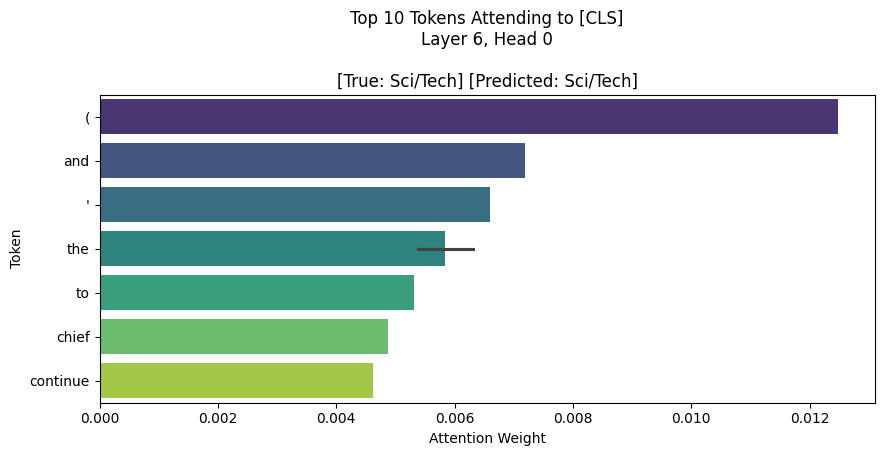

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


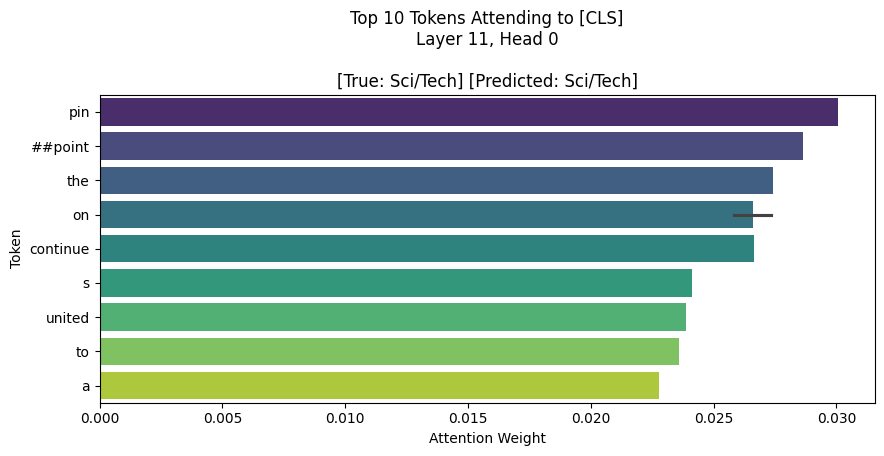

Attention Heatmap, positive example, topic 2


/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


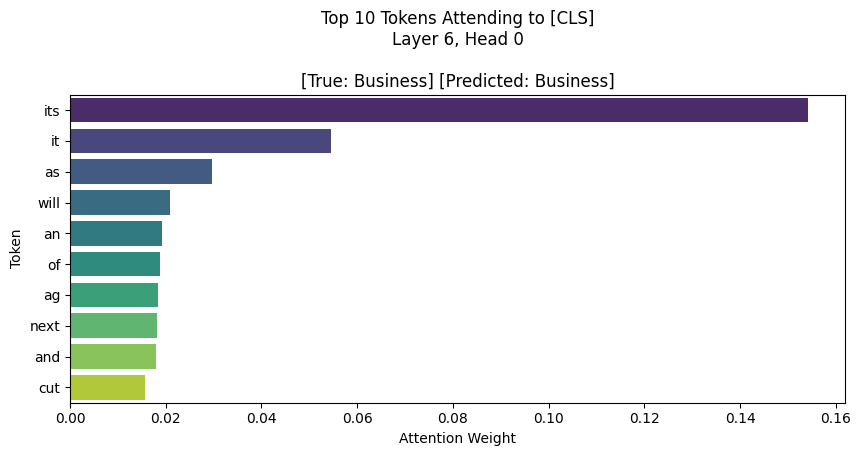

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


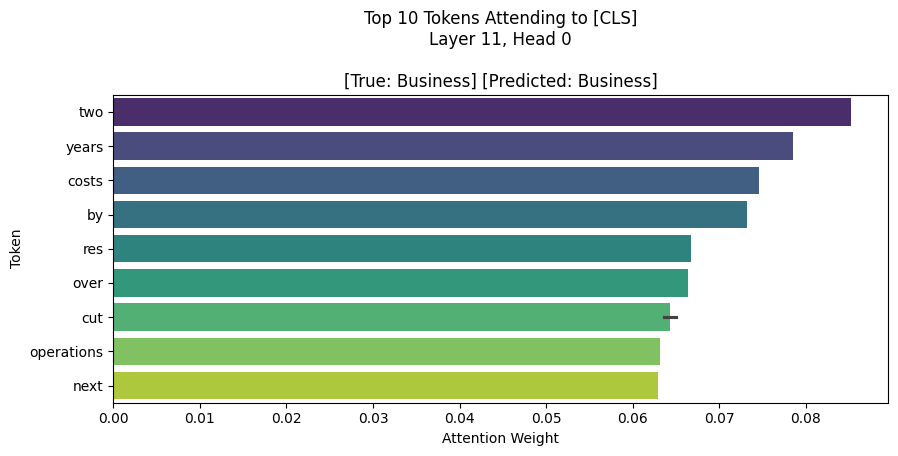

Attention Heatmap, positive example, topic 0


/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


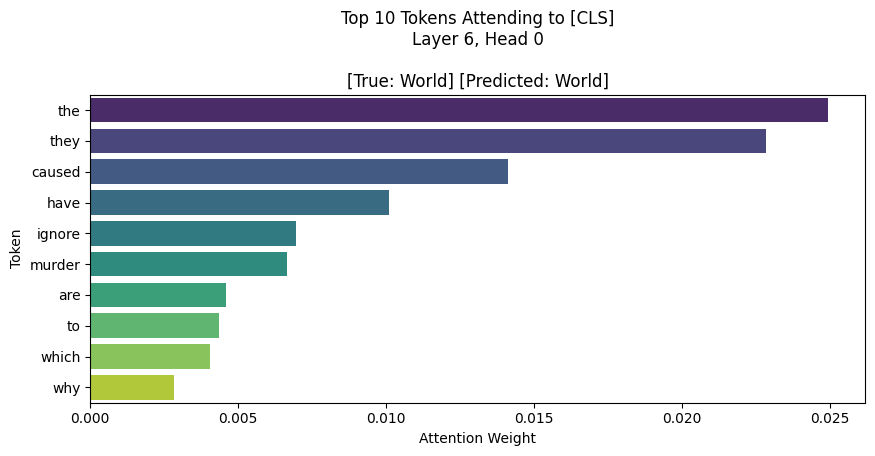

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


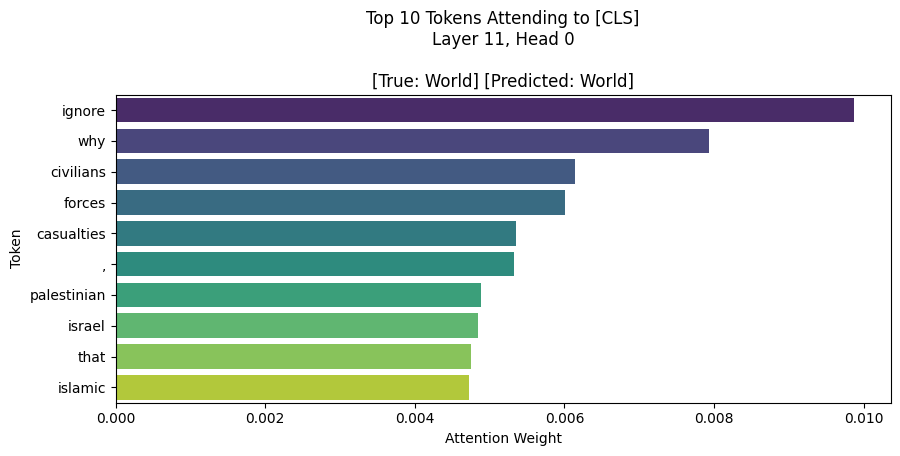

Attention Heatmap, positive example, topic 1


/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


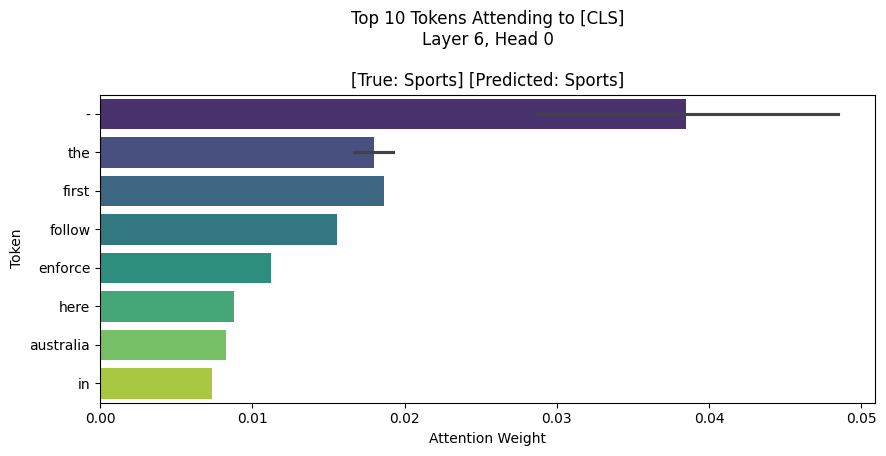

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


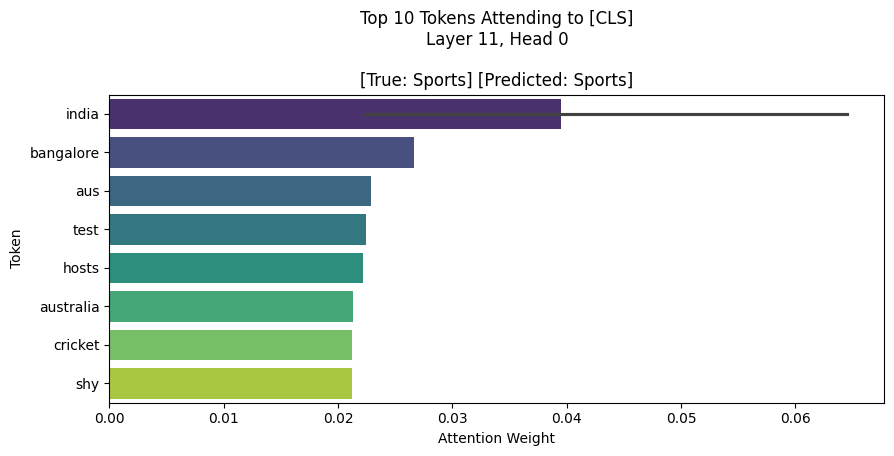

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


Attention Heatmap, negative example, topic 3


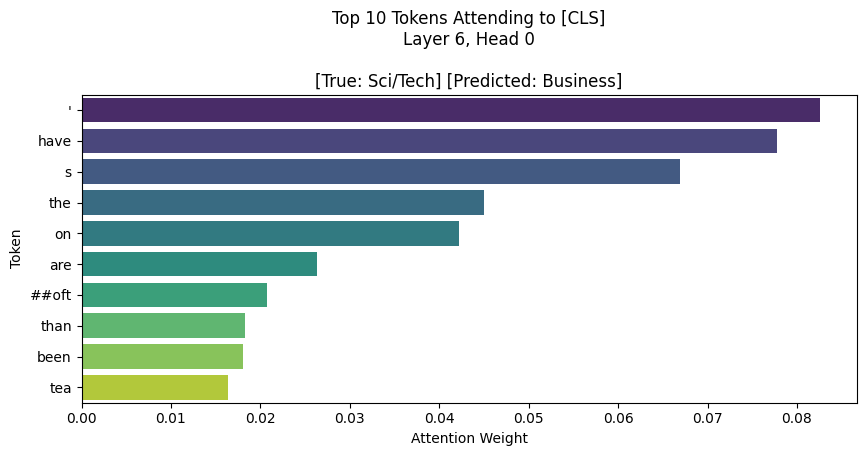

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


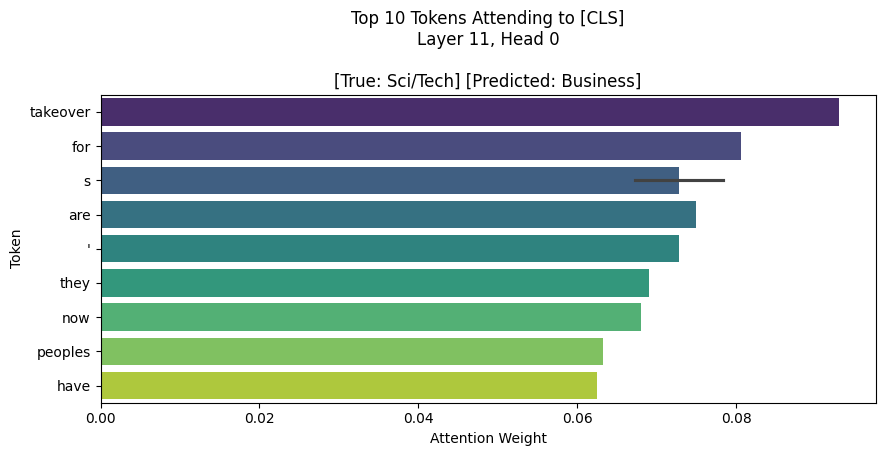

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


Attention Heatmap, negative example, topic 2


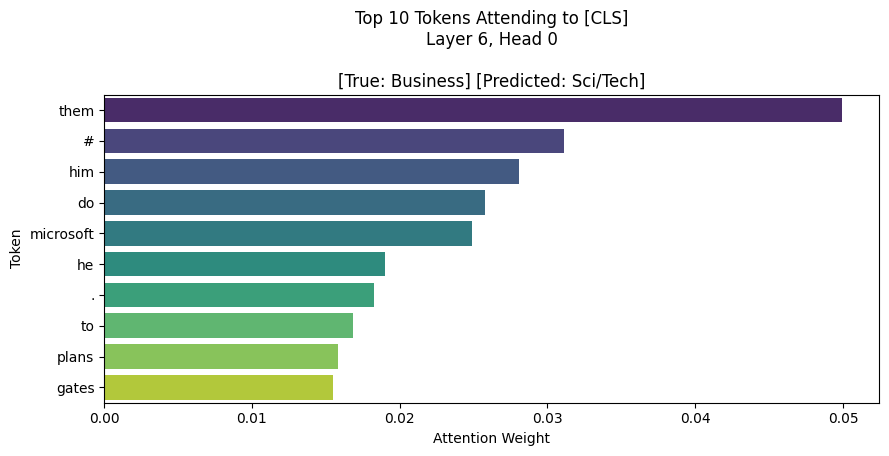

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


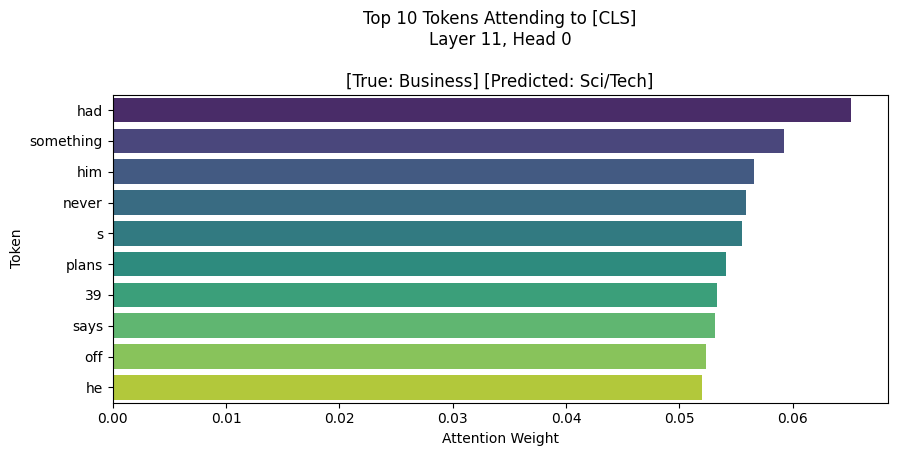

Attention Heatmap, negative example, topic 1


/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


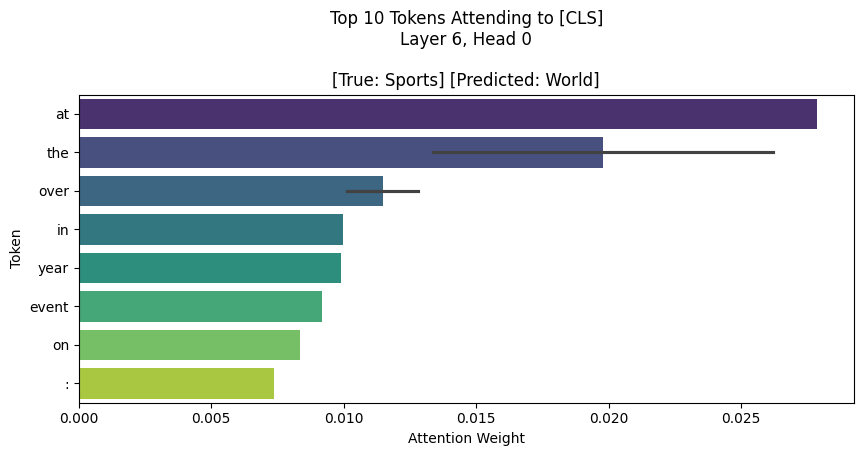

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


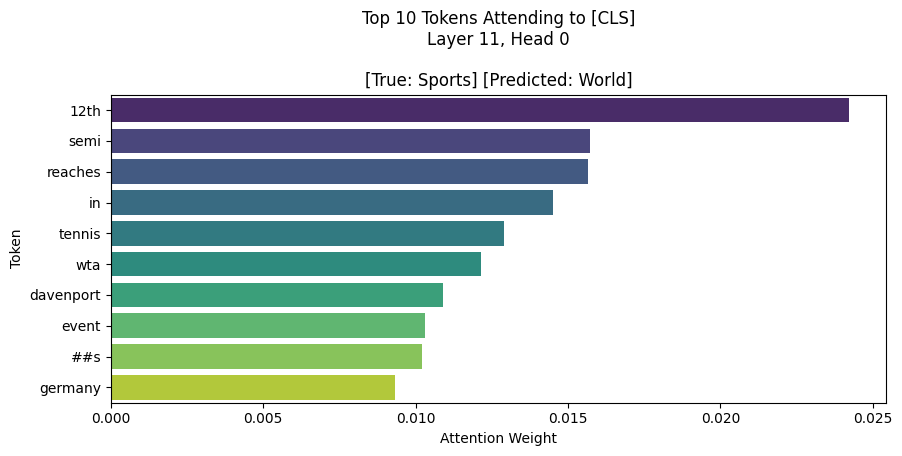

Attention Heatmap, negative example, topic 0


/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


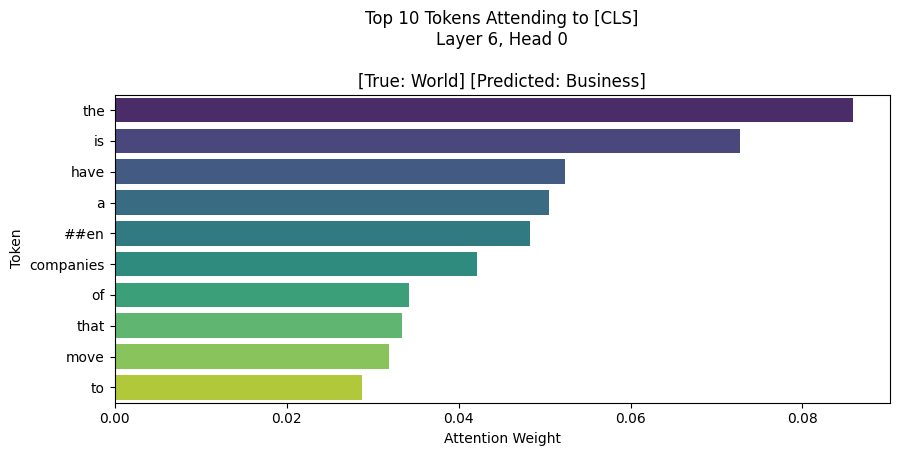

/var/folders/m1/dx4rbxb15tbf7hxs4b996d2m0000gn/T/ipykernel_88700/637509320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_tokens, palette="viridis")


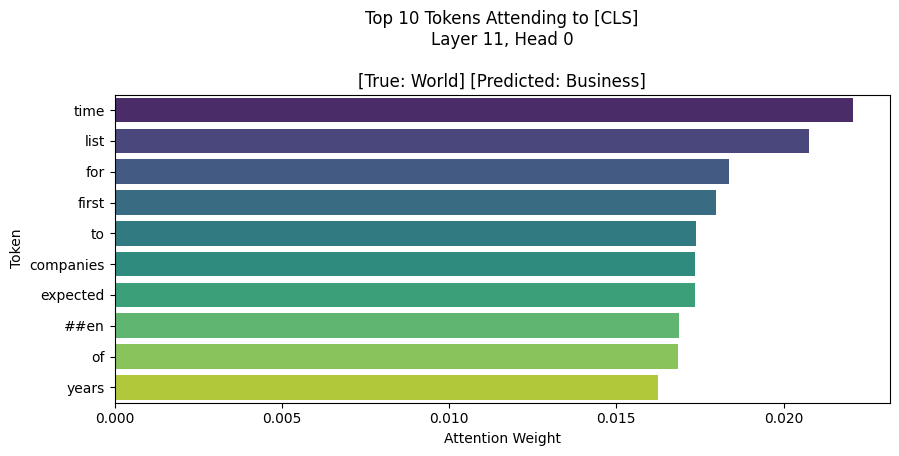

In [ ]:
#DISPLAY GRAPHS FOR EACH EXAMPLE

for ex in positives:
    print(f"Attention Heatmap, positive example, topic {ex['true_label']}")
    note = f"\n[True: {id2label[ex['true_label']]}] [Predicted: {id2label[ex['predicted_label']]}]"
    generate_attention_graphs(ex['text'], note)


for ex in negatives:
    print(f"Attention Heatmap, negative example, topic {ex['true_label']}")
    note = f"\n[True: {id2label[ex['true_label']]}] [Predicted: {id2label[ex['predicted_label']]}]"
    generate_attention_graphs(ex['text'], note)